# **2. Import Library**

In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import GaussianNB
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# **3. Memuat Dataset**

In [103]:
import pandas as pd

# Load file CSV dari folder dataset
train = pd.read_csv('/content/train.csv')
target = pd.read_csv('/content//target.csv')
train = pd.concat([train, target], axis=1)

# Tampilkan beberapa baris pertama
train

,developerCountry,countryCode,userRatingCount,primaryGenreName,downloads,deviceType,hasPrivacyLink,hasTermsOfServiceLink,hasTermsOfServiceLinkRating,isCorporateEmailScore,adSpent,appAge,averageUserRating,appContentBrandSafetyRating,appDescriptionBrandSafetyRating,mfaRating,coppaRisk
0,NORWAY,RO,127731,Sports,NaN,smartphone,True,True,low,99.0,14.017220,160.400000,4.0,medium,low,low,False
1,ADDRESS NOT LISTED IN PLAYSTORE,GLOBAL,0,Medical,50 - 100,GLOBAL,True,NaN,NaN,99.0,NaN,17.500000,0.0,NaN,low,low,False
2,UNITED ARAB EMIRATES,CZ,51143,Games,50000000 - 100000000,GLOBAL,True,True,low,0.0,31.883163,30.766667,4.0,NaN,low,low,False
3,GERMANY,GLOBAL,1074,Games,NaN,GLOBAL,True,NaN,NaN,99.0,NaN,71.533333,4.0,NaN,low,low,False
4,CANNOT IDENTIFY COUNTRY,GLOBAL,17,Tools,1000 - 5000,GLOBAL,True,NaN,NaN,99.0,NaN,52.400000,4.0,NaN,low,low,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6995,ADDRESS NOT LISTED IN PLAYSTORE,GLOBAL,0,Utilities,NaN,GLOBAL,True,NaN,NaN,99.0,NaN,26.266667,0.0,NaN,low,low,False
6996,ADDRESS NOT LISTED IN PLAYSTORE,GLOBAL,0,Business,NaN,GLOBAL,True,NaN,NaN,NaN,NaN,23.800000,0.0,NaN,low,low,False
6997,ADDRESS NOT LISTED IN PLAYSTORE,GLOBAL,0,Personalization,10 - 50,GLOBAL,True,NaN,NaN,0.0,NaN,27.500000,NaN,NaN,medium,low,False
6998,ADDRESS NOT LISTED IN PLAYSTORE,GLOBAL,0,Business,10 - 50,GLOBAL,True,False,high,99.0,NaN,124.033333,0.0,NaN,low,low,False


In [104]:
train.drop(columns=['appContentBrandSafetyRating','adSpent','isCorporateEmailScore','hasTermsOfServiceLinkRating', 'hasTermsOfServiceLink','downloads','averageUserRating'], inplace=True)
train.columns

Index(['developerCountry', 'countryCode', 'userRatingCount',
       'primaryGenreName', 'deviceType', 'hasPrivacyLink', 'appAge',
       'appDescriptionBrandSafetyRating', 'mfaRating', 'coppaRisk'],
      dtype='object')

In [105]:
train.isnull().sum()

,0
developerCountry,0
countryCode,64
userRatingCount,0
primaryGenreName,0
deviceType,0
hasPrivacyLink,750
appAge,50
appDescriptionBrandSafetyRating,0
mfaRating,0
coppaRisk,0


In [106]:

# Calculate the mean of 'appAge' for each group in 'hasPrivacyLink'
mean_appAge_by_privacy = train.groupby('hasPrivacyLink')['appAge'].mean()

# Impute missing 'appAge' values based on 'hasPrivacyLink'
for privacy_link_value in [True, False]:
    train.loc[(train['appAge'].isnull()) & (train['hasPrivacyLink'] == privacy_link_value), 'appAge'] = mean_appAge_by_privacy[privacy_link_value]

train.isnull().sum()

,0
developerCountry,0
countryCode,64
userRatingCount,0
primaryGenreName,0
deviceType,0
hasPrivacyLink,750
appAge,7
appDescriptionBrandSafetyRating,0
mfaRating,0
coppaRisk,0


In [107]:
# Isi nilai kosong di kolom 'countryCode' dengan 'GLOBAL'
train['countryCode'].fillna('GLOBAL', inplace=True)

# Verifikasi kembali jumlah nilai kosong
print(train.isnull().sum())


developerCountry                     0
countryCode                          0
userRatingCount                      0
primaryGenreName                     0
deviceType                           0
hasPrivacyLink                     750
appAge                               7
appDescriptionBrandSafetyRating      0
mfaRating                            0
coppaRisk                            0
dtype: int64


<ipython-input-107-7b1696262225>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train['countryCode'].fillna('GLOBAL', inplace=True)


In [108]:
def impute_privacy_link(row):
    if pd.isnull(row['hasPrivacyLink']):
        # Cek berdasarkan genre yang telah Anda tentukan sebelumnya
        if row['primaryGenreName'] == 'Medical':
            return True
        elif row['primaryGenreName'] == 'Sports':
            if (row['userRatingCount'] < 10) and (row['appAge'] > 95):
                return False
            else:
                return True
        elif row['primaryGenreName'] == 'Games':
            if (row['userRatingCount'] < 10) and (row['appAge'] >= 90):
                return False
            else:
                return True
        elif row['primaryGenreName'] == 'Education':
            if (row['userRatingCount'] < 10) and (row['appAge'] >= 90):
                return False
            else:
                return True
        elif row['primaryGenreName'] == 'Entertainment':
            if (row['userRatingCount'] < 10) and (row['appAge'] >= 90):
                return False
            else:
                return True
        elif row['primaryGenreName'] == 'Business':
            if (row['userRatingCount'] < 10) and (row['appAge'] >= 70):
                return False
            else:
                return True
        elif row['primaryGenreName'] == 'Lifestyle':
            if (row['userRatingCount'] < 10) and (row['appAge'] >= 80):
                return False
            else:
                return True
        elif row['primaryGenreName'] == 'Health & Fitness':
            if (row['userRatingCount'] < 10) and (row['appAge'] >= 85):
                return False
            else:
                return True
        elif row['primaryGenreName'] == 'Social':
            if (row['userRatingCount'] < 10) and (row['appAge'] >= 75):
                return False
            else:
                return True
        elif row['primaryGenreName'] == 'Events':
            if (row['userRatingCount'] < 10) and (row['appAge'] >= 80):
                return False
            else:
                return True
        elif row['primaryGenreName'] == 'News & Magazines':
            if (row['userRatingCount'] < 10) and (row['appAge'] >= 90):
                return False
            else:
                return True
        elif row['primaryGenreName'] == 'Music & Audio':
            if (row['userRatingCount'] < 10) and (row['appAge'] >= 85):
                return False
            else:
                return True
        elif row['primaryGenreName'] == 'Utilities':
            if (row['userRatingCount'] < 10) and (row['appAge'] >= 70):
                return False
            else:
                return True
        elif row['primaryGenreName'] == 'Productivity':
            if (row['userRatingCount'] < 10) and (row['appAge'] >= 80):
                return False
            else:
                return True
        elif row['primaryGenreName'] == 'Photography':
            if (row['userRatingCount'] < 10) and (row['appAge'] >= 90):
                return False
            else:
                return True
        elif row['primaryGenreName'] == 'Comics':
            if (row['userRatingCount'] < 10) and (row['appAge'] >= 85):
                return False
            else:
                return True
        elif row['primaryGenreName'] == 'Maps & Navigation':
            if (row['userRatingCount'] < 10) and (row['appAge'] >= 95):
                return False
            else:
                return True
        elif row['primaryGenreName'] == 'Tools':
            if (row['userRatingCount'] < 10) and (row['appAge'] >= 70):
                return False
            else:
                return True
        elif row['primaryGenreName'] == 'Stickers':
            if (row['userRatingCount'] < 10) and (row['appAge'] >= 80):
                return False
            else:
                return True
        elif row['primaryGenreName'] == 'Food & Drink':
            if (row['userRatingCount'] < 10) and (row['appAge'] >= 85):
                return False
            else:
                return True
        elif row['primaryGenreName'] == 'Photo & Video':
            if (row['userRatingCount'] < 10) and (row['appAge'] >= 90):
                return False
            else:
                return True
        elif row['primaryGenreName'] == 'Books & Reference':
            if (row['userRatingCount'] < 10) and (row['appAge'] >= 90):
                return False
            else:
                return True
        elif row['primaryGenreName'] == 'Personalization':
            if (row['userRatingCount'] < 10) and (row['appAge'] >= 75):
                return False
            else:
                return True
        elif row['primaryGenreName'] == 'Travel':
            if (row['userRatingCount'] < 10) and (row['appAge'] >= 90):
                return False
            else:
                return True
        elif row['primaryGenreName'] == 'Travel & Local':
            if (row['userRatingCount'] < 10) and (row['appAge'] >= 85):
                return False
            else:
                return True
        elif row['primaryGenreName'] == 'Music':
            if (row['userRatingCount'] < 10) and (row['appAge'] >= 90):
                return False
            else:
                return True
        elif row['primaryGenreName'] == 'Shopping':
            if (row['userRatingCount'] < 10) and (row['appAge'] >= 75):
                return False
            else:
                return True
        elif row['primaryGenreName'] == 'Weather':
            if (row['userRatingCount'] < 10) and (row['appAge'] >= 80):
                return False
            else:
                return True
        elif row['primaryGenreName'] == 'Social Networking':
            if (row['userRatingCount'] < 10) and (row['appAge'] >= 70):
                return False
            else:
                return True
        elif row['primaryGenreName'] == 'House & Home':
            if (row['userRatingCount'] < 10) and (row['appAge'] >= 80):
                return False
            else:
                return True
        elif row['primaryGenreName'] == 'Finance':
            if (row['userRatingCount'] < 10) and (row['appAge'] >= 70):
                return False
            else:
                return True
        elif row['primaryGenreName'] == 'Reference':
            if (row['userRatingCount'] < 10) and (row['appAge'] >= 75):
                return False
            else:
                return True
        elif row['primaryGenreName'] == 'Art & Design':
            if (row['userRatingCount'] < 10) and (row['appAge'] >= 85):
                return False
            else:
                return True
        elif row['primaryGenreName'] == 'Beauty':
            if (row['userRatingCount'] < 10) and (row['appAge'] >= 80):
                return False
            else:
                return True
        elif row['primaryGenreName'] == 'Communication':
            if (row['userRatingCount'] < 10) and (row['appAge'] >= 75):
                return False
            else:
                return True
        elif row['primaryGenreName'] == 'News':
            if (row['userRatingCount'] < 10) and (row['appAge'] >= 90):
                return False
            else:
                return True
        elif row['primaryGenreName'] == 'Auto & Vehicles':
            if (row['userRatingCount'] < 10) and (row['appAge'] >= 80):
                return False
            else:
                return True
        elif row['primaryGenreName'] == 'Book':
            if (row['userRatingCount'] < 10) and (row['appAge'] >= 70):
                return False
            else:
                return True
        elif row['primaryGenreName'] == 'Navigation':
            if (row['userRatingCount'] < 10) and (row['appAge'] >= 95):
                return False
            else:
                return True
        elif row['primaryGenreName'] == 'Video Players & Editors':
            if (row['userRatingCount'] < 10) and (row['appAge'] >= 80):
                return False
            else:
                return True
        else:
            # Aturan default jika genre belum tertangani
            return True  # Misalnya, Anda memilih untuk mengisi dengan True untuk genre yang tidak teridentifikasi

    return row['hasPrivacyLink']

# Terapkan lagi fungsi untuk mengisi nilai kosong
train['hasPrivacyLink'] = train.apply(impute_privacy_link, axis=1)


In [109]:
mean_appAge_by_privacy = train.groupby('hasPrivacyLink')['appAge'].mean()

# Impute missing 'appAge' values based on 'hasPrivacyLink'
for privacy_link_value in [True, False]:
    train.loc[(train['appAge'].isnull()) & (train['hasPrivacyLink'] == privacy_link_value), 'appAge'] = mean_appAge_by_privacy[privacy_link_value]
train.isnull().sum()

,0
developerCountry,0
countryCode,0
userRatingCount,0
primaryGenreName,0
deviceType,0
hasPrivacyLink,0
appAge,0
appDescriptionBrandSafetyRating,0
mfaRating,0
coppaRisk,0


In [110]:
train

,developerCountry,countryCode,userRatingCount,primaryGenreName,deviceType,hasPrivacyLink,appAge,appDescriptionBrandSafetyRating,mfaRating,coppaRisk
0,NORWAY,RO,127731,Sports,smartphone,True,160.400000,low,low,False
1,ADDRESS NOT LISTED IN PLAYSTORE,GLOBAL,0,Medical,GLOBAL,True,17.500000,low,low,False
2,UNITED ARAB EMIRATES,CZ,51143,Games,GLOBAL,True,30.766667,low,low,False
3,GERMANY,GLOBAL,1074,Games,GLOBAL,True,71.533333,low,low,False
4,CANNOT IDENTIFY COUNTRY,GLOBAL,17,Tools,GLOBAL,True,52.400000,low,low,False
...,...,...,...,...,...,...,...,...,...,...
6995,ADDRESS NOT LISTED IN PLAYSTORE,GLOBAL,0,Utilities,GLOBAL,True,26.266667,low,low,False
6996,ADDRESS NOT LISTED IN PLAYSTORE,GLOBAL,0,Business,GLOBAL,True,23.800000,low,low,False
6997,ADDRESS NOT LISTED IN PLAYSTORE,GLOBAL,0,Personalization,GLOBAL,True,27.500000,medium,low,False
6998,ADDRESS NOT LISTED IN PLAYSTORE,GLOBAL,0,Business,GLOBAL,True,124.033333,low,low,False


# **3. Sampling**

In [111]:
import pandas as pd
from sklearn.utils import resample

# Cek jumlah data per kombinasi
group_counts = train.groupby(['hasPrivacyLink', 'coppaRisk']).size()
print(group_counts)

hasPrivacyLink  coppaRisk
False           False         329
                True           31
True            False        5975
                True          665
dtype: int64


In [112]:
# Dapatkan jumlah maksimum sebagai target penyamaan
max_count = group_counts.max()

# Buat list untuk simpan data yang sudah di-resample
resampled_groups = []

# Loop tiap grup berdasarkan kombinasi
for (hplink, risk), group in train.groupby(['hasPrivacyLink', 'coppaRisk']):
    n_samples = max_count - len(group)
    if n_samples > 0:
        # Tambahkan data secara random dengan pengulangan
        group_upsampled = resample(group,
                                   replace=True,
                                   n_samples=n_samples,
                                   random_state=42)
        group = pd.concat([group, group_upsampled])
    resampled_groups.append(group)

# Gabungkan semua grup yang telah di-resample
df_balanced = pd.concat(resampled_groups)

# Cek hasilnya
print(df_balanced.groupby(['hasPrivacyLink', 'coppaRisk']).size())

hasPrivacyLink  coppaRisk
False           False        5975
                True         5975
True            False        5975
                True         5975
dtype: int64


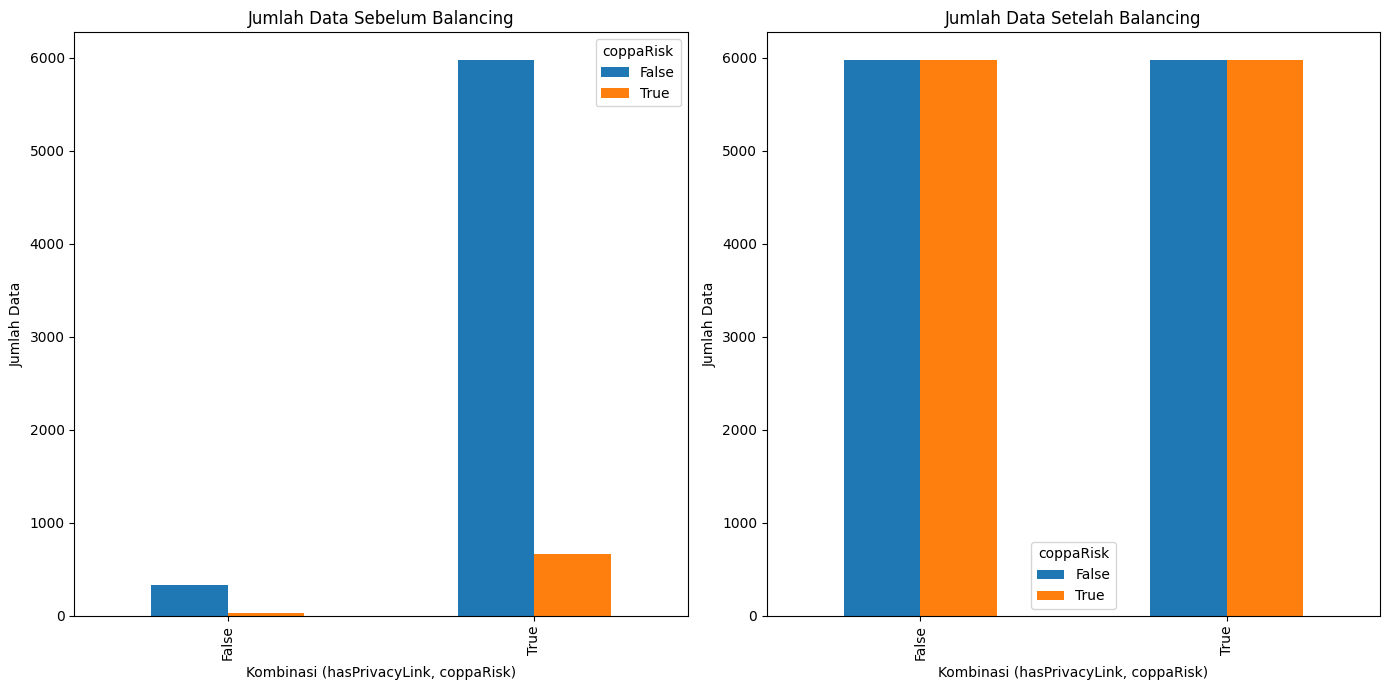

In [113]:
import matplotlib.pyplot as plt

# Hitung jumlah data per kombinasi sebelum balancing
group_counts_before = train.groupby(['hasPrivacyLink', 'coppaRisk']).size()

# Hitung jumlah data per kombinasi setelah balancing
group_counts_after = df_balanced.groupby(['hasPrivacyLink', 'coppaRisk']).size()

# Plotting bar chart
fig, ax = plt.subplots(1, 2, figsize=(14, 7))

# Bar chart untuk sebelum balancing
group_counts_before.unstack().plot(kind='bar', ax=ax[0])
ax[0].set_title('Jumlah Data Sebelum Balancing')
ax[0].set_xlabel('Kombinasi (hasPrivacyLink, coppaRisk)')
ax[0].set_ylabel('Jumlah Data')

# Bar chart untuk setelah balancing
group_counts_after.unstack().plot(kind='bar', ax=ax[1])
ax[1].set_title('Jumlah Data Setelah Balancing')
ax[1].set_xlabel('Kombinasi (hasPrivacyLink, coppaRisk)')
ax[1].set_ylabel('Jumlah Data')

plt.tight_layout()
plt.show()


# **3. MODELING**

**Encoding**

In [114]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

df = df_balanced.copy()

# Mapping ordinal untuk risk rating
ordinal_map = {'low': 0, 'medium': 1, 'high': 2}
df['appDescriptionBrandSafetyRating'] = df['appDescriptionBrandSafetyRating'].str.lower().map(ordinal_map)
df['mfaRating'] = df['mfaRating'].str.lower().map(ordinal_map)

# Deteksi kolom kategorik selain yang sudah di-handle
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
ordinal_cols = ['appDescriptionBrandSafetyRating', 'mfaRating']
df['hasPrivacyLink'] = df['hasPrivacyLink'].astype(int)
df['coppaRisk'] = df['coppaRisk'].astype(int)
# Label encode kolom kategorik selain ordinal
le = LabelEncoder()
for col in categorical_cols:
    if col not in ordinal_cols:
        df[col] = le.fit_transform(df[col].astype(str))

In [115]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

# --- 1. Baca data ---
# train = pd.read_csv('train.csv')
# df = df_balanced.copy()

# --- 4. Siapkan fitur dan target ---
x = df.drop(columns=['coppaRisk','developerCountry','countryCode'])
y = df['coppaRisk'].astype(int)

# --- 5. Split data ---
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# --- 6. Terapkan SMOTE ---
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

# --- 7. Grid Search untuk berbagai model ---

# Grid search untuk XGBoost
params_xgb = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],
    'n_estimators': [100, 200],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1]
}

grid_search_xgb = GridSearchCV(
    estimator=XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    param_grid=params_xgb,
    scoring='accuracy',
    cv=3,
    verbose=1,
    n_jobs=-1
)

# Grid search untuk Random Forest
params_rf = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_search_rf = GridSearchCV(
    estimator=RandomForestClassifier(),
    param_grid=params_rf,
    scoring='accuracy',
    cv=3,
    verbose=1,
    n_jobs=-1
)

# Grid search untuk K-Nearest Neighbors (KNN)
params_knn = {
    'n_neighbors': [3, 5, 7],
    'weights': ['uniform', 'distance'],
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute']
}

grid_search_knn = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=params_knn,
    scoring='accuracy',
    cv=3,
    verbose=1,
    n_jobs=-1
)

# Grid search untuk Decision Tree
params_dt = {
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'criterion': ['gini', 'entropy']
}

grid_search_dt = GridSearchCV(
    estimator=DecisionTreeClassifier(),
    param_grid=params_dt,
    scoring='accuracy',
    cv=3,
    verbose=1,
    n_jobs=-1
)

# Grid search untuk Naive Bayes
grid_search_nb = GridSearchCV(
    estimator=GaussianNB(),
    param_grid={},
    scoring='accuracy',
    cv=3,
    verbose=1,
    n_jobs=-1
)

# Grid search untuk Neural Network
params_nn = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50)],
    'activation': ['tanh', 'relu'],
    'solver': ['adam', 'sgd'],
    'max_iter': [100, 200]
}

grid_search_nn = GridSearchCV(
    estimator=MLPClassifier(),
    param_grid=params_nn,
    scoring='accuracy',
    cv=3,
    verbose=1,
    n_jobs=-1
)

# Grid search untuk Gradient Boosting Machine (GBM)
params_gbm = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1, 0.3],
    'max_depth': [3, 5, 7]
}

grid_search_gbm = GridSearchCV(
    estimator=GradientBoostingClassifier(),
    param_grid=params_gbm,
    scoring='accuracy',
    cv=3,
    verbose=1,
    n_jobs=-1
)

# Latih semua model menggunakan GridSearchCV
grid_search_xgb.fit(X_resampled, y_resampled)
grid_search_rf.fit(X_resampled, y_resampled)
grid_search_knn.fit(X_resampled, y_resampled)
grid_search_dt.fit(X_resampled, y_resampled)
grid_search_nb.fit(X_resampled, y_resampled)
grid_search_nn.fit(X_resampled, y_resampled)
grid_search_gbm.fit(X_resampled, y_resampled)

# --- 8. Evaluasi model terbaik ---
# XGBoost
y_pred_xgb = grid_search_xgb.predict(X_test)
y_pred_str_xgb = pd.Series(y_pred_xgb).map({0: 'false', 1: 'true'})
y_test_str = y_test.map({0: 'false', 1: 'true'})

# Random Forest
y_pred_rf = grid_search_rf.predict(X_test)
y_pred_str_rf = pd.Series(y_pred_rf).map({0: 'false', 1: 'true'})

# K-Nearest Neighbors
y_pred_knn = grid_search_knn.predict(X_test)
y_pred_str_knn = pd.Series(y_pred_knn).map({0: 'false', 1: 'true'})

# Decision Tree
y_pred_dt = grid_search_dt.predict(X_test)
y_pred_str_dt = pd.Series(y_pred_dt).map({0: 'false', 1: 'true'})

# Naive Bayes
y_pred_nb = grid_search_nb.predict(X_test)
y_pred_str_nb = pd.Series(y_pred_nb).map({0: 'false', 1: 'true'})

# Neural Network
y_pred_nn = grid_search_nn.predict(X_test)
y_pred_str_nn = pd.Series(y_pred_nn).map({0: 'false', 1: 'true'})

# GBM
y_pred_gbm = grid_search_gbm.predict(X_test)
y_pred_str_gbm = pd.Series(y_pred_gbm).map({0: 'false', 1: 'true'})

# Tampilkan parameter terbaik
print("Best parameters for XGBoost: ", grid_search_xgb.best_params_)
print("Best parameters for Random Forest: ", grid_search_rf.best_params_)
print("Best parameters for K-Nearest Neighbors: ", grid_search_knn.best_params_)
print("Best parameters for Decision Tree: ", grid_search_dt.best_params_)
print("Best parameters for Naive Bayes: ", grid_search_nb.best_params_)
print("Best parameters for Neural Network: ", grid_search_nn.best_params_)
print("Best parameters for GBM: ", grid_search_gbm.best_params_)

# Evaluasi dengan classification report untuk setiap model
print("\nClassification Report for XGBoost:")
print(classification_report(y_test_str, y_pred_str_xgb))

print("\nClassification Report for Random Forest:")
print(classification_report(y_test_str, y_pred_str_rf))

print("\nClassification Report for K-Nearest Neighbors:")
print(classification_report(y_test_str, y_pred_str_knn))

print("\nClassification Report for Decision Tree:")
print(classification_report(y_test_str, y_pred_str_dt))

print("\nClassification Report for Naive Bayes:")
print(classification_report(y_test_str, y_pred_str_nb))

print("\nClassification Report for Neural Network:")
print(classification_report(y_test_str, y_pred_str_nn))

print("\nClassification Report for GBM:")
print(classification_report(y_test_str, y_pred_str_gbm))


Fitting 3 folds for each of 72 candidates, totalling 216 fits


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [08:09:25] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Fitting 3 folds for each of 24 candidates, totalling 72 fits
Fitting 3 folds for each of 24 candidates, totalling 72 fits
Fitting 3 folds for each of 24 candidates, totalling 72 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 24 candidates, totalling 72 fits


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Fitting 3 folds for each of 18 candidates, totalling 54 fits
Best parameters for XGBoost:  {'colsample_bytree': 1, 'learning_rate': 0.3, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}
Best parameters for Random Forest:  {'max_depth': 7, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best parameters for K-Nearest Neighbors:  {'algorithm': 'auto', 'n_neighbors': 3, 'weights': 'distance'}
Best parameters for Decision Tree:  {'criterion': 'gini', 'max_depth': 7, 'min_samples_leaf': 2, 'min_samples_split': 2}
Best parameters for Naive Bayes:  {}
Best parameters for Neural Network:  {'activation': 'tanh', 'hidden_layer_sizes': (100,), 'max_iter': 200, 'solver': 'adam'}
Best parameters for GBM:  {'learning_rate': 0.3, 'max_depth': 7, 'n_estimators': 200}

Classification Report for XGBoost:
              precision    recall  f1-score   support

       false       0.99      0.94      0.97      2411
        true       0.94      0.99      0.97      2369

    accuracy 

In [116]:
from sklearn.metrics import roc_auc_score

# --- 9. Evaluasi AUC untuk setiap model ---
# XGBoost
auc_xgb = roc_auc_score(y_test, grid_search_xgb.predict_proba(X_test)[:, 1])
print(f"AUC for XGBoost: {auc_xgb:.4f}")

# Random Forest
auc_rf = roc_auc_score(y_test, grid_search_rf.predict_proba(X_test)[:, 1])
print(f"AUC for Random Forest: {auc_rf:.4f}")

# K-Nearest Neighbors
auc_knn = roc_auc_score(y_test, grid_search_knn.predict_proba(X_test)[:, 1])
print(f"AUC for K-Nearest Neighbors: {auc_knn:.4f}")

# Decision Tree
auc_dt = roc_auc_score(y_test, grid_search_dt.predict_proba(X_test)[:, 1])
print(f"AUC for Decision Tree: {auc_dt:.4f}")

# Naive Bayes
auc_nb = roc_auc_score(y_test, grid_search_nb.predict_proba(X_test)[:, 1])
print(f"AUC for Naive Bayes: {auc_nb:.4f}")

# Neural Network
auc_nn = roc_auc_score(y_test, grid_search_nn.predict_proba(X_test)[:, 1])
print(f"AUC for Neural Network: {auc_nn:.4f}")

# GBM
auc_gbm = roc_auc_score(y_test, grid_search_gbm.predict_proba(X_test)[:, 1])
print(f"AUC for GBM: {auc_gbm:.4f}")


AUC for XGBoost: 0.9916
AUC for Random Forest: 0.9467
AUC for K-Nearest Neighbors: 0.9709
AUC for Decision Tree: 0.9297
AUC for Naive Bayes: 0.6960
AUC for Neural Network: 0.8907
AUC for GBM: 0.9962


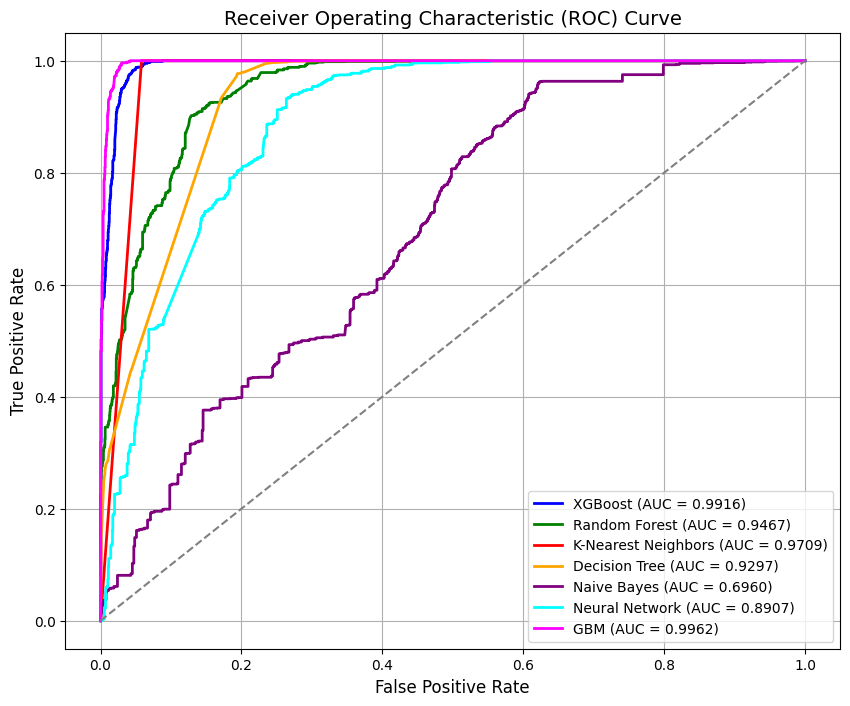

In [117]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# --- 10. Plot ROC Curve untuk setiap model ---
# XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, grid_search_xgb.predict_proba(X_test)[:, 1])
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, grid_search_rf.predict_proba(X_test)[:, 1])
roc_auc_rf = auc(fpr_rf, tpr_rf)

# K-Nearest Neighbors
fpr_knn, tpr_knn, _ = roc_curve(y_test, grid_search_knn.predict_proba(X_test)[:, 1])
roc_auc_knn = auc(fpr_knn, tpr_knn)

# Decision Tree
fpr_dt, tpr_dt, _ = roc_curve(y_test, grid_search_dt.predict_proba(X_test)[:, 1])
roc_auc_dt = auc(fpr_dt, tpr_dt)

# Naive Bayes
fpr_nb, tpr_nb, _ = roc_curve(y_test, grid_search_nb.predict_proba(X_test)[:, 1])
roc_auc_nb = auc(fpr_nb, tpr_nb)

# Neural Network
fpr_nn, tpr_nn, _ = roc_curve(y_test, grid_search_nn.predict_proba(X_test)[:, 1])
roc_auc_nn = auc(fpr_nn, tpr_nn)

# GBM
fpr_gbm, tpr_gbm, _ = roc_curve(y_test, grid_search_gbm.predict_proba(X_test)[:, 1])
roc_auc_gbm = auc(fpr_gbm, tpr_gbm)

# --- 11. Plot ROC Curve ---
plt.figure(figsize=(10, 8))

# Plot each model's ROC curve
plt.plot(fpr_xgb, tpr_xgb, color='blue', lw=2, label=f'XGBoost (AUC = {roc_auc_xgb:.4f})')
plt.plot(fpr_rf, tpr_rf, color='green', lw=2, label=f'Random Forest (AUC = {roc_auc_rf:.4f})')
plt.plot(fpr_knn, tpr_knn, color='red', lw=2, label=f'K-Nearest Neighbors (AUC = {roc_auc_knn:.4f})')
plt.plot(fpr_dt, tpr_dt, color='orange', lw=2, label=f'Decision Tree (AUC = {roc_auc_dt:.4f})')
plt.plot(fpr_nb, tpr_nb, color='purple', lw=2, label=f'Naive Bayes (AUC = {roc_auc_nb:.4f})')
plt.plot(fpr_nn, tpr_nn, color='cyan', lw=2, label=f'Neural Network (AUC = {roc_auc_nn:.4f})')
plt.plot(fpr_gbm, tpr_gbm, color='magenta', lw=2, label=f'GBM (AUC = {roc_auc_gbm:.4f})')

# Plotting the diagonal line for random guesses (AUC = 0.5)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')

# Formatting the plot
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


In [118]:
# import pandas as pd
# from sklearn.preprocessing import LabelEncoder
# from xgboost import XGBClassifier
# from sklearn.metrics import classification_report
# from sklearn.model_selection import train_test_split
# from imblearn.over_sampling import SMOTE
# from sklearn.model_selection import GridSearchCV

# # --- 1. Baca data ---
# # train = pd.read_csv('train.csv')
# # df = df_balanced.copy()

# # --- 4. Siapkan fitur dan target ---
# x = df.drop(columns=['coppaRisk','developerCountry','countryCode'])
# y = df['coppaRisk'].astype(int)

# # --- 5. Split data ---
# X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# # --- 6. Terapkan SMOTE ---
# smote = SMOTE(random_state=42)
# X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

# # --- 7. Latih model XGBoost dengan GridSearchCV ---
# params = {
#     'max_depth': [3, 5, 7],
#     'learning_rate': [0.01, 0.1, 0.3],
#     'n_estimators': [100, 200],
#     'subsample': [0.8, 1],
#     'colsample_bytree': [0.8, 1]
# }

# grid_search = GridSearchCV(
#     estimator=XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
#     param_grid=params,
#     scoring='accuracy',
#     cv=3,
#     verbose=1,
#     n_jobs=-1
# )

# grid_search.fit(X_resampled, y_resampled)

# # --- 8. Evaluasi model terbaik ---
# y_pred = grid_search.predict(X_test)

# # Konversi hasil prediksi dari 0/1 menjadi 'false'/'true'
# y_pred_str = pd.Series(y_pred).map({0: 'false', 1: 'true'})
# y_test_str = y_test.map({0: 'false', 1: 'true'})

# # Tampilkan parameter terbaik
# print("Best parameters found: ", grid_search.best_params_)

# # Evaluasi dengan classification report
# print(classification_report(y_test_str, y_pred_str))


# **3. Test**

In [119]:
test = pd.read_csv('/content/test.csv')
submission_format = pd.read_csv('/content/submission_format.csv')

In [120]:
test.drop(columns=['ID','appContentBrandSafetyRating','adSpent','isCorporateEmailScore','hasTermsOfServiceLinkRating', 'hasTermsOfServiceLink','downloads','averageUserRating'], inplace=True)
test.columns

# Calculate the mean of 'appAge' for each group in 'hasPrivacyLink'
mean_appAge_by_privacy = test.groupby('hasPrivacyLink')['appAge'].mean()

# Impute missing 'appAge' values based on 'hasPrivacyLink'
for privacy_link_value in [True, False]:
    test.loc[(test['appAge'].isnull()) & (test['hasPrivacyLink'] == privacy_link_value), 'appAge'] = mean_appAge_by_privacy[privacy_link_value]

test.isnull().sum()

# Isi nilai kosong di kolom 'countryCode' dengan 'GLOBAL'
test['countryCode'].fillna('GLOBAL', inplace=True)

# Verifikasi kembali jumlah nilai kosong
print(test.isnull().sum())


def impute_privacy_link(row):
    if pd.isnull(row['hasPrivacyLink']):
        # Cek berdasarkan genre yang telah Anda tentukan sebelumnya
        if row['primaryGenreName'] == 'Medical':
            return True
        elif row['primaryGenreName'] == 'Sports':
            if (row['userRatingCount'] < 10) and (row['appAge'] > 95):
                return False
            else:
                return True
        elif row['primaryGenreName'] == 'Games':
            if (row['userRatingCount'] < 10) and (row['appAge'] >= 90):
                return False
            else:
                return True
        elif row['primaryGenreName'] == 'Education':
            if (row['userRatingCount'] < 10) and (row['appAge'] >= 90):
                return False
            else:
                return True
        elif row['primaryGenreName'] == 'Entertainment':
            if (row['userRatingCount'] < 10) and (row['appAge'] >= 90):
                return False
            else:
                return True
        elif row['primaryGenreName'] == 'Business':
            if (row['userRatingCount'] < 10) and (row['appAge'] >= 70):
                return False
            else:
                return True
        elif row['primaryGenreName'] == 'Lifestyle':
            if (row['userRatingCount'] < 10) and (row['appAge'] >= 80):
                return False
            else:
                return True
        elif row['primaryGenreName'] == 'Health & Fitness':
            if (row['userRatingCount'] < 10) and (row['appAge'] >= 85):
                return False
            else:
                return True
        elif row['primaryGenreName'] == 'Social':
            if (row['userRatingCount'] < 10) and (row['appAge'] >= 75):
                return False
            else:
                return True
        elif row['primaryGenreName'] == 'Events':
            if (row['userRatingCount'] < 10) and (row['appAge'] >= 80):
                return False
            else:
                return True
        elif row['primaryGenreName'] == 'News & Magazines':
            if (row['userRatingCount'] < 10) and (row['appAge'] >= 90):
                return False
            else:
                return True
        elif row['primaryGenreName'] == 'Music & Audio':
            if (row['userRatingCount'] < 10) and (row['appAge'] >= 85):
                return False
            else:
                return True
        elif row['primaryGenreName'] == 'Utilities':
            if (row['userRatingCount'] < 10) and (row['appAge'] >= 70):
                return False
            else:
                return True
        elif row['primaryGenreName'] == 'Productivity':
            if (row['userRatingCount'] < 10) and (row['appAge'] >= 80):
                return False
            else:
                return True
        elif row['primaryGenreName'] == 'Photography':
            if (row['userRatingCount'] < 10) and (row['appAge'] >= 90):
                return False
            else:
                return True
        elif row['primaryGenreName'] == 'Comics':
            if (row['userRatingCount'] < 10) and (row['appAge'] >= 85):
                return False
            else:
                return True
        elif row['primaryGenreName'] == 'Maps & Navigation':
            if (row['userRatingCount'] < 10) and (row['appAge'] >= 95):
                return False
            else:
                return True
        elif row['primaryGenreName'] == 'Tools':
            if (row['userRatingCount'] < 10) and (row['appAge'] >= 70):
                return False
            else:
                return True
        elif row['primaryGenreName'] == 'Stickers':
            if (row['userRatingCount'] < 10) and (row['appAge'] >= 80):
                return False
            else:
                return True
        elif row['primaryGenreName'] == 'Food & Drink':
            if (row['userRatingCount'] < 10) and (row['appAge'] >= 85):
                return False
            else:
                return True
        elif row['primaryGenreName'] == 'Photo & Video':
            if (row['userRatingCount'] < 10) and (row['appAge'] >= 90):
                return False
            else:
                return True
        elif row['primaryGenreName'] == 'Books & Reference':
            if (row['userRatingCount'] < 10) and (row['appAge'] >= 90):
                return False
            else:
                return True
        elif row['primaryGenreName'] == 'Personalization':
            if (row['userRatingCount'] < 10) and (row['appAge'] >= 75):
                return False
            else:
                return True
        elif row['primaryGenreName'] == 'Travel':
            if (row['userRatingCount'] < 10) and (row['appAge'] >= 90):
                return False
            else:
                return True
        elif row['primaryGenreName'] == 'Travel & Local':
            if (row['userRatingCount'] < 10) and (row['appAge'] >= 85):
                return False
            else:
                return True
        elif row['primaryGenreName'] == 'Music':
            if (row['userRatingCount'] < 10) and (row['appAge'] >= 90):
                return False
            else:
                return True
        elif row['primaryGenreName'] == 'Shopping':
            if (row['userRatingCount'] < 10) and (row['appAge'] >= 75):
                return False
            else:
                return True
        elif row['primaryGenreName'] == 'Weather':
            if (row['userRatingCount'] < 10) and (row['appAge'] >= 80):
                return False
            else:
                return True
        elif row['primaryGenreName'] == 'Social Networking':
            if (row['userRatingCount'] < 10) and (row['appAge'] >= 70):
                return False
            else:
                return True
        elif row['primaryGenreName'] == 'House & Home':
            if (row['userRatingCount'] < 10) and (row['appAge'] >= 80):
                return False
            else:
                return True
        elif row['primaryGenreName'] == 'Finance':
            if (row['userRatingCount'] < 10) and (row['appAge'] >= 70):
                return False
            else:
                return True
        elif row['primaryGenreName'] == 'Reference':
            if (row['userRatingCount'] < 10) and (row['appAge'] >= 75):
                return False
            else:
                return True
        elif row['primaryGenreName'] == 'Art & Design':
            if (row['userRatingCount'] < 10) and (row['appAge'] >= 85):
                return False
            else:
                return True
        elif row['primaryGenreName'] == 'Beauty':
            if (row['userRatingCount'] < 10) and (row['appAge'] >= 80):
                return False
            else:
                return True
        elif row['primaryGenreName'] == 'Communication':
            if (row['userRatingCount'] < 10) and (row['appAge'] >= 75):
                return False
            else:
                return True
        elif row['primaryGenreName'] == 'News':
            if (row['userRatingCount'] < 10) and (row['appAge'] >= 90):
                return False
            else:
                return True
        elif row['primaryGenreName'] == 'Auto & Vehicles':
            if (row['userRatingCount'] < 10) and (row['appAge'] >= 80):
                return False
            else:
                return True
        elif row['primaryGenreName'] == 'Book':
            if (row['userRatingCount'] < 10) and (row['appAge'] >= 70):
                return False
            else:
                return True
        elif row['primaryGenreName'] == 'Navigation':
            if (row['userRatingCount'] < 10) and (row['appAge'] >= 95):
                return False
            else:
                return True
        elif row['primaryGenreName'] == 'Video Players & Editors':
            if (row['userRatingCount'] < 10) and (row['appAge'] >= 80):
                return False
            else:
                return True
        else:
            # Aturan default jika genre belum tertangani
            return True  # Misalnya, Anda memilih untuk mengisi dengan True untuk genre yang tidak teridentifikasi

    return row['hasPrivacyLink']

# Terapkan lagi fungsi untuk mengisi nilai kosong
test['hasPrivacyLink'] = test.apply(impute_privacy_link, axis=1)


mean_appAge_by_privacy = test.groupby('hasPrivacyLink')['appAge'].mean()

# Impute missing 'appAge' values based on 'hasPrivacyLink'
for privacy_link_value in [True, False]:
    test.loc[(test['appAge'].isnull()) & (test['hasPrivacyLink'] == privacy_link_value), 'appAge'] = mean_appAge_by_privacy[privacy_link_value]
test.isnull().sum()

ordinal_map = {'low': 0, 'medium': 1, 'high': 2}
test['appDescriptionBrandSafetyRating'] = test['appDescriptionBrandSafetyRating'].str.lower().map(ordinal_map)
test['mfaRating'] = test['mfaRating'].str.lower().map(ordinal_map)

categorical_cols = test.select_dtypes(include=['object']).columns.tolist()
ordinal_cols = ['appDescriptionBrandSafetyRating', 'mfaRating']

test['hasPrivacyLink'] = test['hasPrivacyLink'].astype(int)

le = LabelEncoder()
for col in categorical_cols:
    if col not in ordinal_cols:
        test[col] = le.fit_transform(test[col].astype(str))




developerCountry                     0
countryCode                          0
userRatingCount                      0
primaryGenreName                     0
deviceType                           0
hasPrivacyLink                     316
appAge                               2
appDescriptionBrandSafetyRating      0
mfaRating                            0
dtype: int64


<ipython-input-120-1da5068fc175>:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test['countryCode'].fillna('GLOBAL', inplace=True)


In [127]:
# Salin format submission
submission = submission_format.copy()

# Tentukan X_test (dengan menghapus kolom yang tidak digunakan dalam pelatihan)
X_test = test.drop(columns=['developerCountry', 'countryCode'])

# Prediksi menggunakan model terbaik dari GridSearch
y_submission_pred = grid_search_xgb.predict(X_test)

# Ubah hasil prediksi dari 0/1 menjadi 'false'/'true'
submission['coppaRisk'] = pd.Series(y_submission_pred).map({0: 'false', 1: 'true'})

# Simpan hasil ke file CSV
submission.to_csv("/content/submission3.csv", index=False)

# Tampilkan hasil yang sudah disimpan
print(submission[['ID', 'coppaRisk']])


        ID coppaRisk
0     2807     false
1     1742      true
2      806      true
3     2635     false
4     9047     false
...    ...       ...
2995  2288     false
2996  5541     false
2997  9259     false
2998  3477     false
2999  6406     false

[3000 rows x 2 columns]
